# Etape 5  : Interprétation et Visualisation


### Préparation des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

# Configuration de l'affichage
plt.rcParams['figure.figsize'] = (12, 6)

#Chargement et Nettoyage
df = pd.read_csv('../data.csv', sep=';')

# Conversion des types pour les calculs
df['CVSS'] = pd.to_numeric(df['CVSS'], errors='coerce')
df['EPSS'] = pd.to_numeric(df['EPSS'], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', utc=True)

# Extraction des entités "Editeur" et "Produit"
def extract_entities(title):
    if pd.isna(title): return "Inconnu", "Inconnu"
    title = title.replace("les produits ", "").replace("le produit ", "")
    match = re.search(r'dans ([\w\s\-\.]+)', title)
    if match:
        parts = match.group(1).split()
        vendor = parts[0]
        product = " ".join(parts[1:3]) if len(parts) > 1 else "Générique"
        return vendor, product
    return "Autre", "Autre"

df[['Editeur', 'Produit']] = df['Titre ANSSI'].apply(lambda x: pd.Series(extract_entities(x)))

### Génération des graphiques

1. Histogramme des scores CVSS et Sévérité

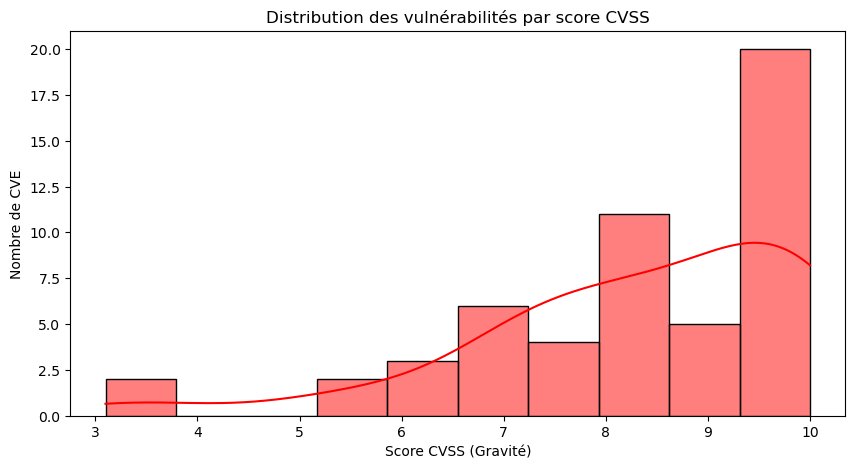

In [2]:
plt.figure(figsize = (10, 5))
sns.histplot(df['CVSS'].dropna() , bins=10,  kde=True, color='red')
plt.title('Distribution des vulnérabilités par score CVSS')
plt.xlabel('Score CVSS (Gravité)')
plt.ylabel('Nombre de CVE')
plt.show()

2. Diagramme circulaire des types de failles (CWE)

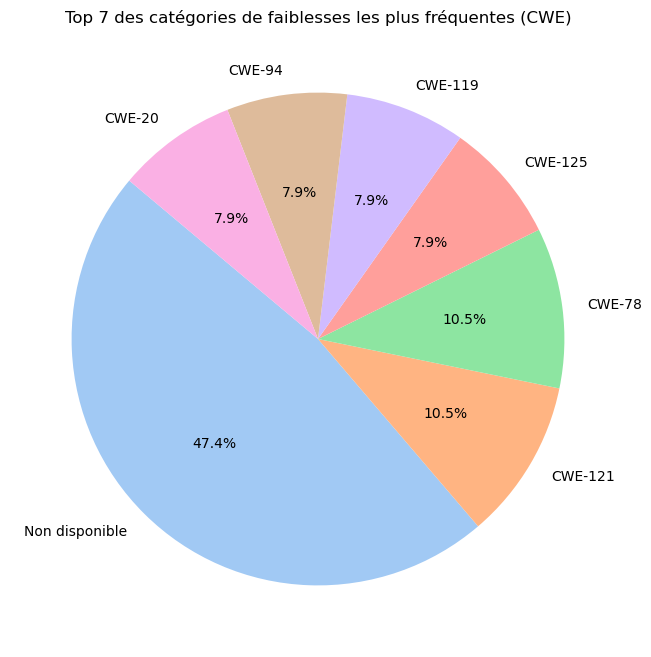

In [3]:
cwe_counts = df['CWE'].value_counts().head(7)
plt.figure(figsize=(8, 8))
plt.pie(cwe_counts, labels=cwe_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Top 7 des catégories de faiblesses les plus fréquentes (CWE)')
plt.show()

3. Nuage de points et Corrélation CVSS vs EPSS

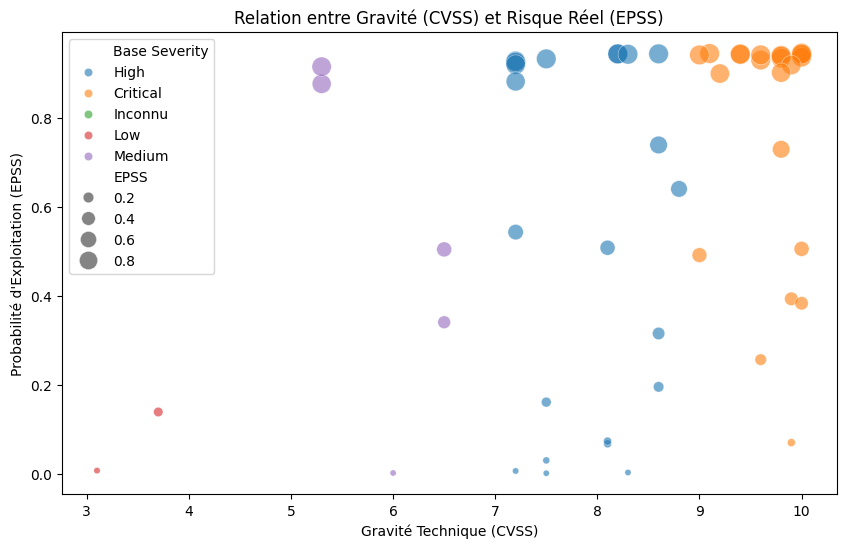

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CVSS', y='EPSS', hue='Base Severity', size='EPSS', sizes=(20, 200), alpha=0.6)
plt.title('Relation entre Gravité (CVSS) et Risque Réel (EPSS)')
plt.xlabel('Gravité Technique (CVSS)')
plt.ylabel('Probabilité d\'Exploitation (EPSS)')
plt.show()

4. Analyse par Éditeur (Ranking et Type de bulletin)

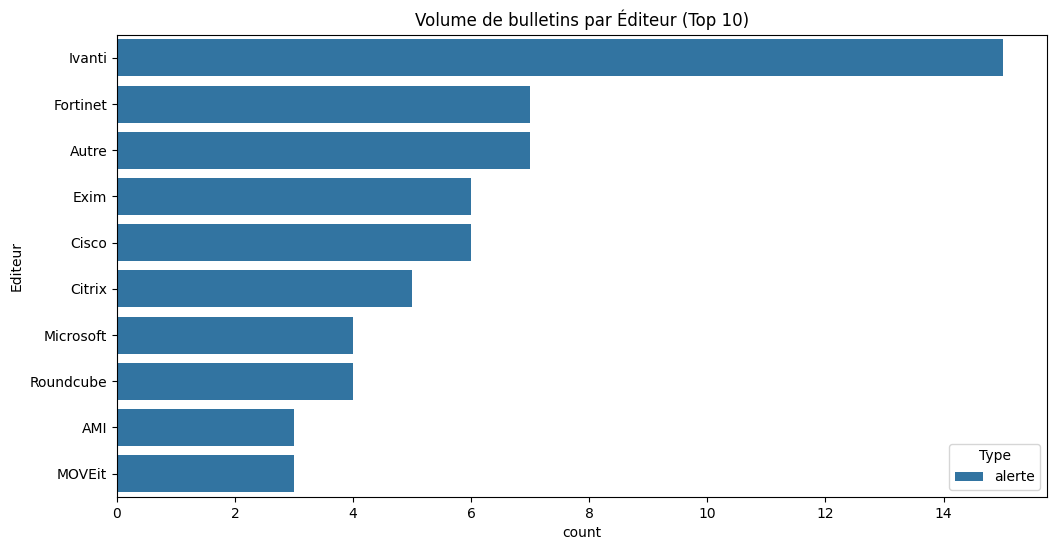

In [6]:
top_vendors = df['Editeur'].value_counts().head(10).index
df_top = df[df['Editeur'].isin(top_vendors)]


plt.figure(figsize=(12, 6))
sns.countplot(data=df_top, y='Editeur', hue='Type',  order=top_vendors)
plt.title('Volume de bulletins par Éditeur (Top 10)')
plt.show()

5. Évolution temporelle cumulative

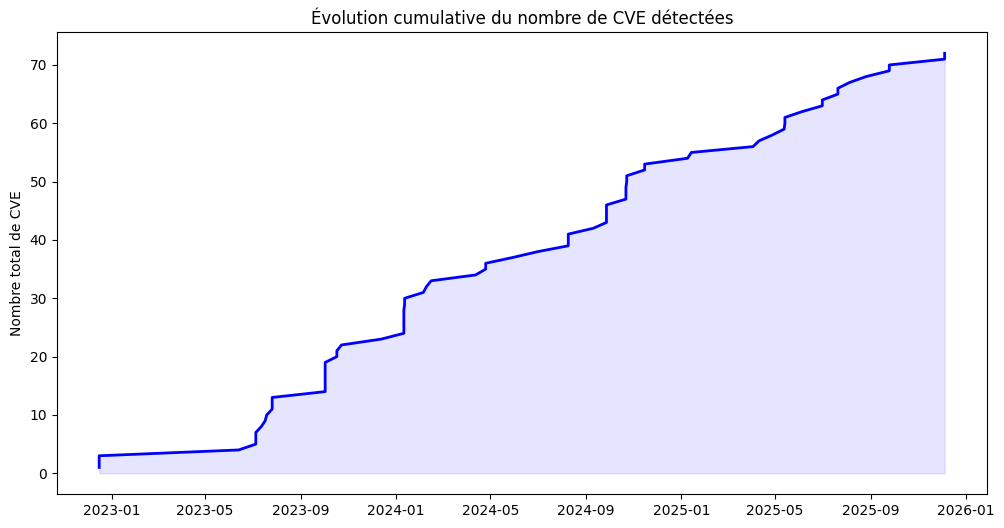

In [7]:
df_temp = df.dropna(subset=['Date']).sort_values('Date')
df_temp['total'] = range(1, len(df_temp) + 1)

plt.figure(figsize=(12, 6))
plt.plot(df_temp['Date'], df_temp['total'], color='blue', linewidth=2)
plt.fill_between(df_temp['Date'], df_temp['total'], color='blue', alpha=0.1)
plt.title('Évolution cumulative du nombre de CVE détectées')
plt.ylabel('Nombre total de CVE')
plt.show()

6. Boxplot de la dispersion CVSS par Éditeur

C:\Users\zouad\AppData\Local\Temp\ipykernel_28828\2834951332.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_vendors, x='Editeur', y='CVSS', palette='Set3')


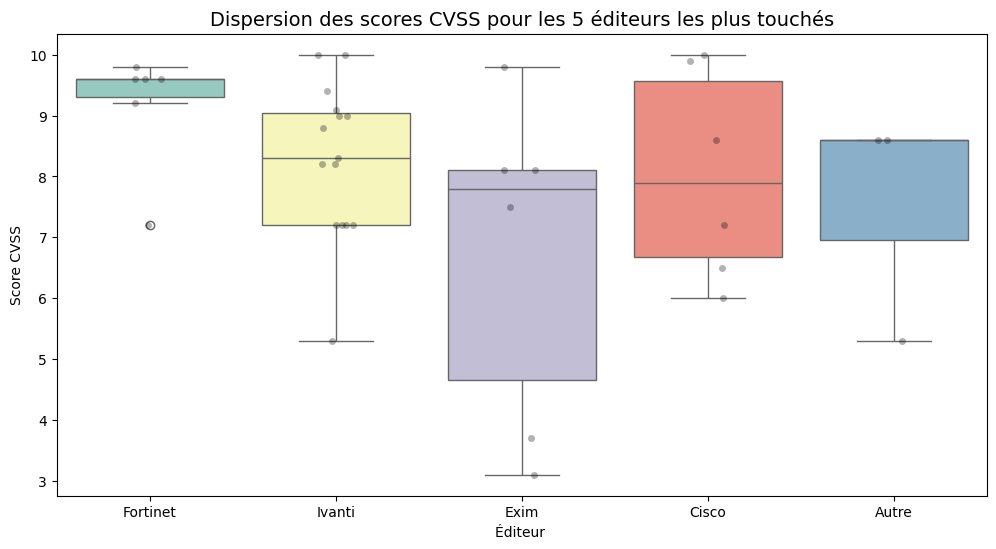

In [8]:
top_5_vendors = df['Editeur'].value_counts().head(5).index
df_top_vendors = df[df['Editeur'].isin(top_5_vendors)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_vendors, x='Editeur', y='CVSS', palette='Set3')
sns.stripplot(data=df_top_vendors, x='Editeur', y='CVSS', color='black', alpha=0.3) 

plt.title('Dispersion des scores CVSS pour les 5 éditeurs les plus touchés', fontsize=14)
plt.xlabel('Éditeur ')
plt.ylabel('Score CVSS')
plt.show()

7. Courbe des scores EPSS (Distribution de la probabilité)

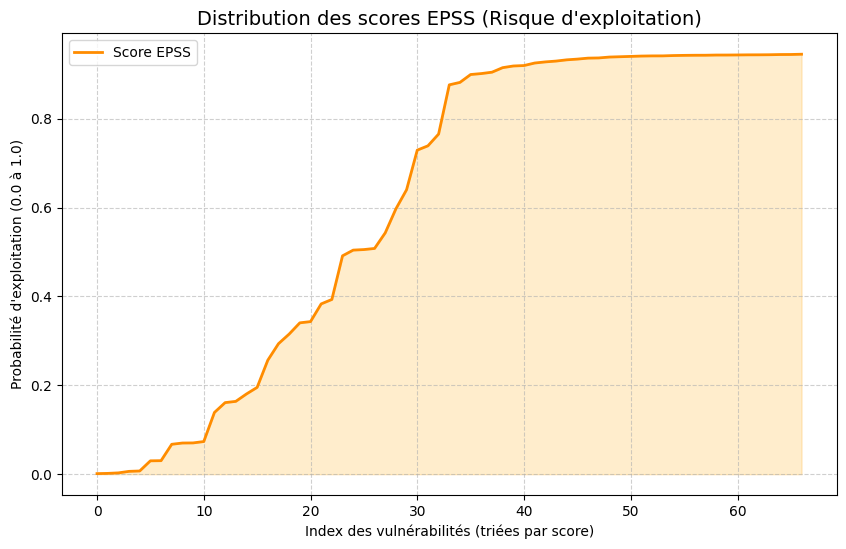

In [9]:

epss_sorted = df['EPSS'].dropna().sort_values().reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.plot(epss_sorted, color='darkorange', linewidth=2, label='Score EPSS')
plt.fill_between(range(len(epss_sorted)), epss_sorted, color='orange', alpha=0.2)

plt.title('Distribution des scores EPSS (Risque d\'exploitation)', fontsize=14)
plt.xlabel('Index des vulnérabilités (triées par score)')
plt.ylabel('Probabilité d\'exploitation (0.0 à 1.0)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

8. Heatmap des corrélations CVSS et EPSS

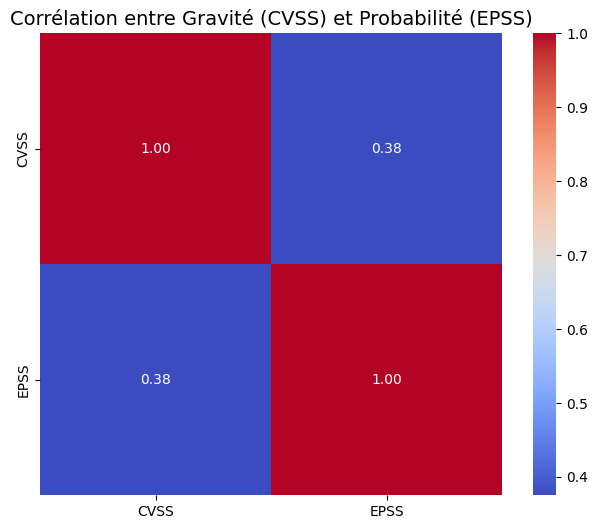

In [10]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[['CVSS', 'EPSS']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Corrélation entre Gravité (CVSS) et Probabilité (EPSS)', fontsize=14)
plt.show()

9. Focus sur un type de vulnérabilité (CWE spécifique)

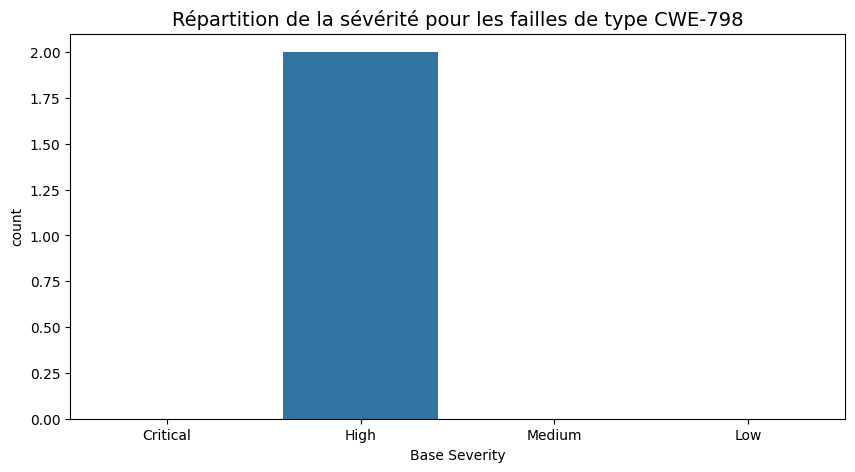

In [11]:
target_cwe = "CWE-798" 
df_cwe = df[df['CWE'] == target_cwe]

if not df_cwe.empty:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df_cwe, x='Base Severity', order=["Critical", "High", "Medium", "Low"])
    plt.title(f'Répartition de la sévérité pour les failles de type {target_cwe}', fontsize=14)
    plt.show()
else:
    print(f"Aucune donnée trouvée pour {target_cwe}")

10. Analyse des versions de produits

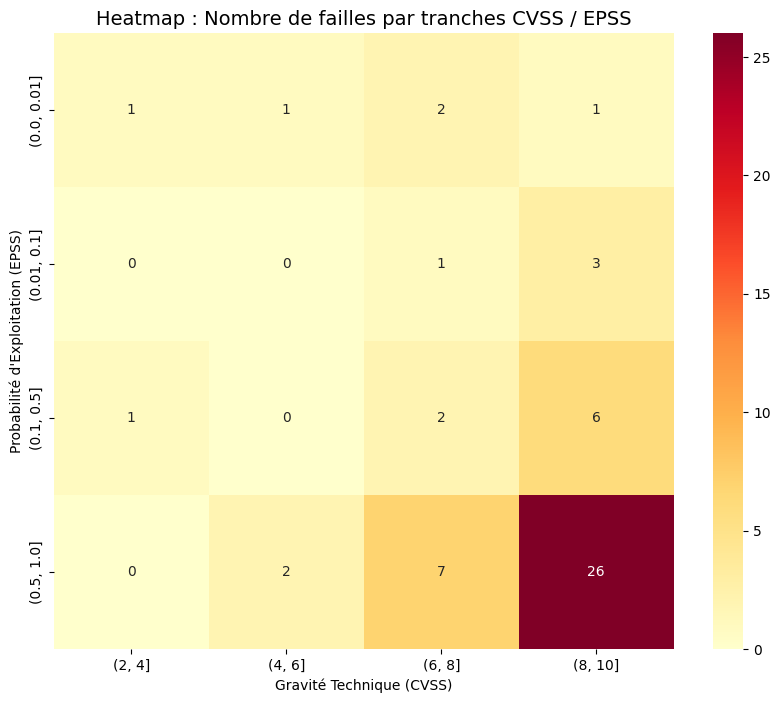

In [12]:

df_heat = df.dropna(subset=['CVSS', 'EPSS']).copy()
df_heat['CVSS_bins'] = pd.cut(df_heat['CVSS'], bins=range(0, 12, 2))
df_heat['EPSS_bins'] = pd.cut(df_heat['EPSS'], bins=[0, 0.01, 0.1, 0.5, 1.0])

pivot_table = df_heat.pivot_table(index='EPSS_bins', columns='CVSS_bins', aggfunc='size', fill_value=0, observed=True)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, cmap="YlOrRd", fmt='d')
plt.title("Heatmap : Nombre de failles par tranches CVSS / EPSS", fontsize=14)
plt.xlabel("Gravité Technique (CVSS)")
plt.ylabel("Probabilité d'Exploitation (EPSS)")
plt.show()

11. Profil de Failles par Éditeur

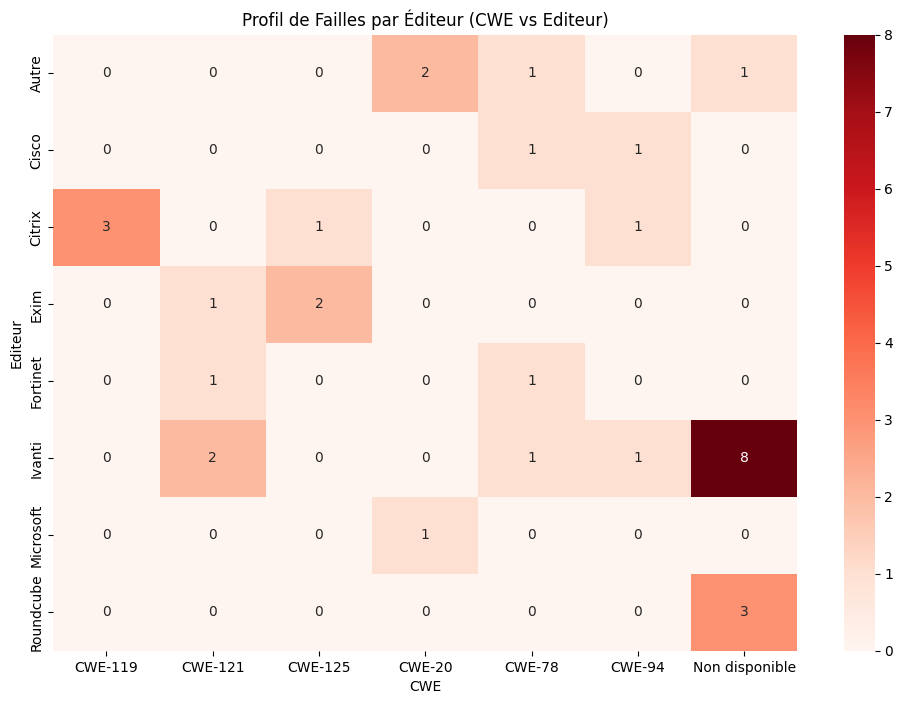

In [13]:

top_vendors = df['Editeur'].value_counts().head(8).index
top_cwes = df['CWE'].value_counts().head(8).index
df_filtered = df[df['Editeur'].isin(top_vendors) & df['CWE'].isin(top_cwes)]

ct = pd.crosstab(df_filtered['Editeur'], df_filtered['CWE'])
plt.figure(figsize=(12, 8))
sns.heatmap(ct, annot=True, cmap='Reds', fmt='d')
plt.title('Profil de Failles par Éditeur (CWE vs Editeur)')
plt.show()

12. Comparaison de la Sévérité : Avis vs Alertes

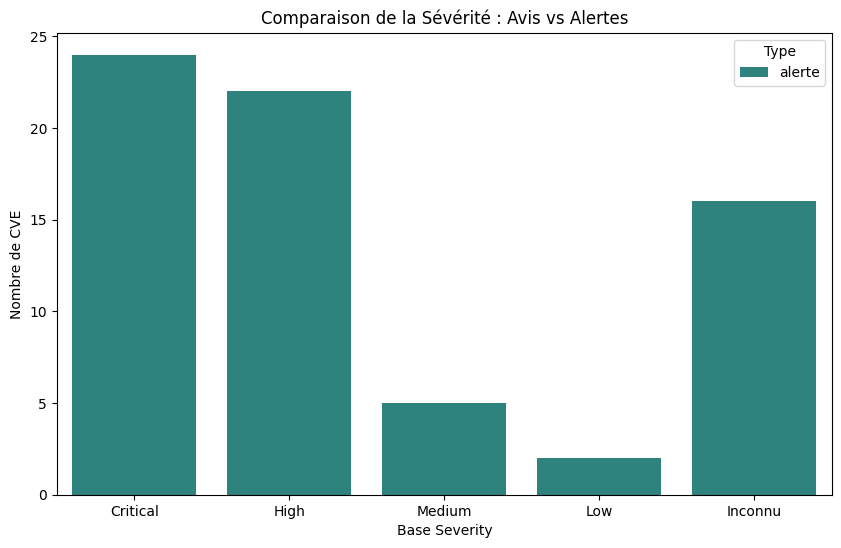

In [14]:
plt.figure(figsize=(10, 6))
severity_order = ["Critical", "High", "Medium", "Low", "Inconnu"]
sns.countplot(data=df, x='Base Severity', hue='Type', order=severity_order, palette='viridis')
plt.title('Comparaison de la Sévérité : Avis vs Alertes')
plt.ylabel('Nombre de CVE')
plt.show()